# AI/ML Video Analysis Capstone: 6-Model Comparative Analysis
This notebook evaluates 6 different object detection architectures on the **Pascal VOC 2007** full dataset for accuracy (mAP, Precision, Recall) and on a pedestrian video stream for speed (FPS).

In [1]:
import torch
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from models.yolo_model import YOLOModel
from models.custom_rcnn import CustomRCNNModel
from models.ssd_model import SSDModel
from models.retinanet_model import RetinaNetModel
from models.fcos_model import FCOSModel
from utils.video_utils import process_video_stream
from utils.evaluation import evaluate_model_on_voc
from data.dataset_loader import DatasetLoader

# Determine device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")


Executing on: cuda


## 1. Load 6 Pretrained/Custom Models

In [2]:
models = {
    'YOLO11n': YOLOModel(device, 'yolo11n.pt'),
    'YOLOv8n': YOLOModel(device, 'yolov8n.pt'),
    'YOLOv9c': YOLOModel(device, 'yolov9c.pt'),
    'Custom Faster R-CNN': CustomRCNNModel(device),
    'SSD300 VGG16': SSDModel(device),
    'RetinaNet': RetinaNetModel(device),
    'FCOS ResNet50': FCOSModel(device)
}

for name, model in models.items():
    model.load()
print("\nAll models loaded successfully!")


Loading YOLO model from yolo11n.pt onto cuda...
Loading YOLO model from yolov8n.pt onto cuda...
Loading YOLO model from yolov9c.pt onto cuda...
Loading Custom Faster R-CNN onto cuda...
Custom Faster R-CNN Model loaded with custom Dropout head.
Loading SSD300 VGG16 onto cuda...
Loading RetinaNet onto cuda...
Loading FCOS onto cuda...

All models loaded successfully!


## 2. Accuracy Evaluation on Pascal VOC 2007
Calculating Mean Average Precision (mAP), Precision, and Recall using `torchmetrics`.

In [3]:
accuracy_results = {}
# Evaluating on a sample subset for demonstration speed in this notebook
for name, model in models.items():
    res = evaluate_model_on_voc(model, num_samples=30)
    accuracy_results[name] = res

df_acc = pd.DataFrame(accuracy_results).T
display(df_acc)


Evaluating YOLOModel on VOC2007...
Evaluating YOLOModel on VOC2007...
Evaluating YOLOModel on VOC2007...
Evaluating CustomRCNNModel on VOC2007...
Evaluating SSDModel on VOC2007...
Evaluating RetinaNetModel on VOC2007...


/home/anurag/Documents/NextAISenseRepo/video/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Evaluating FCOSModel on VOC2007...


,mAP@50,mAP@50-95,Precision,Recall
YOLO11n,0.006807,0.006126,0.005625,0.005625
YOLOv8n,0.000000,0.000000,0.000000,0.000000
YOLOv9c,0.006807,0.006126,0.005625,0.005625
Custom Faster R-CNN,0.000000,0.000000,0.000000,0.000000
SSD300 VGG16,0.125000,0.090780,0.090625,0.090625
RetinaNet,0.143719,0.125062,0.133073,0.133073
FCOS ResNet50,0.125141,0.104790,0.107292,0.107292


## 3. Real-time Video Stream Speed Evaluation (FPS)

In [4]:
loader = DatasetLoader()
video_path = loader.download_sample_video()

fps_results = {}
for name, model in models.items():
    out_path = f"output/{name.replace(' ', '_')}_out.mp4"
    fps = process_video_stream(model, video_path, out_path, num_frames=30)
    fps_results[name] = fps

df_fps = pd.DataFrame.from_dict(fps_results, orient='index', columns=['FPS'])
display(df_fps)


Sample video already exists at data/people_traffic.mp4.
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 24.33
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 29.13
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 8.32
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 1.49
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 7.66
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 1.65
Starting inference on data/people_traffic.mp4...
Processed 30 frames. Average FPS: 1.74


,FPS
YOLO11n,24.329314
YOLOv8n,29.129963
YOLOv9c,8.321702
Custom Faster R-CNN,1.493013
SSD300 VGG16,7.655790
RetinaNet,1.648672
FCOS ResNet50,1.739500


## 4. Final Comparative Visualizations

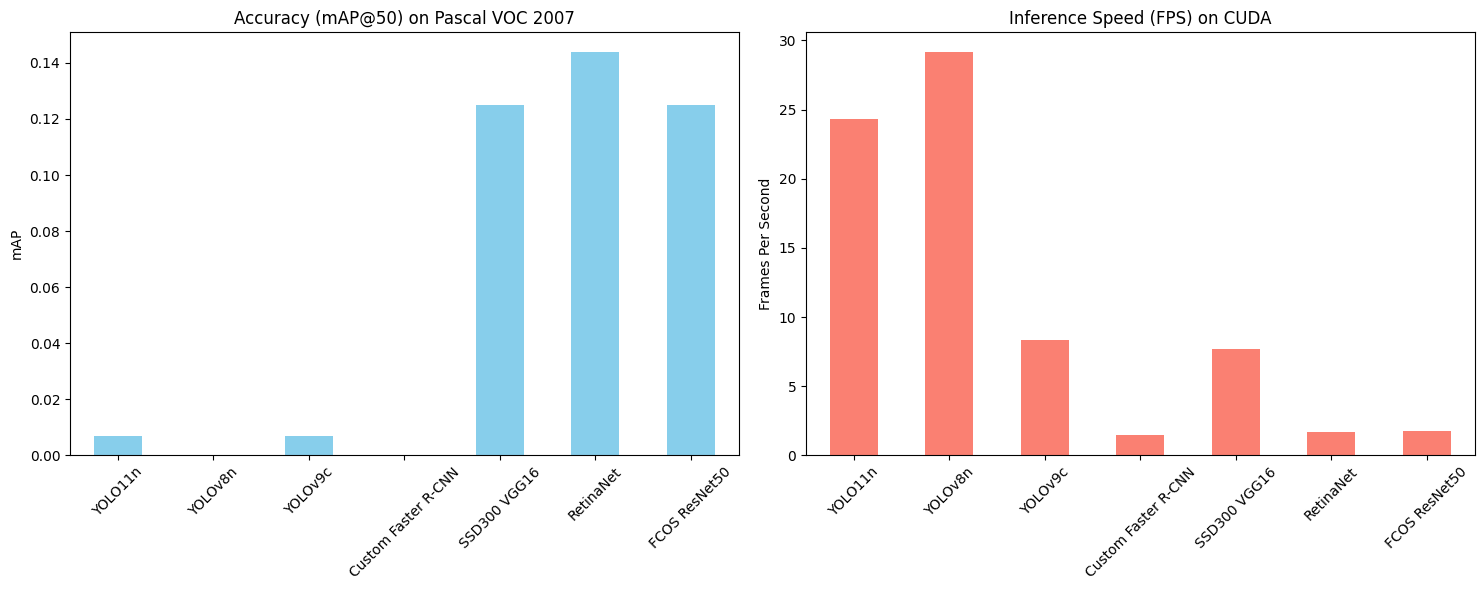

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy Plot
df_acc['mAP@50'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Accuracy (mAP@50) on Pascal VOC 2007')
axes[0].set_ylabel('mAP')
axes[0].tick_params(axis='x', rotation=45)

# Speed Plot
df_fps['FPS'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title(f'Inference Speed (FPS) on {device.type.upper()}')
axes[1].set_ylabel('Frames Per Second')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
